In [ ]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal

In [ ]:
true_data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/navierstokes/u.Re=4000:T=3:None.npy')
pred_bad = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/fixed_scaling_prelim/uhat.npy')
predictions = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/log/neurips/ns.T3re4.length0.4/hyperparameter_tuning/NSM_hdim32_depth10_mode12_41_41_lr0.001/uhat.npy')

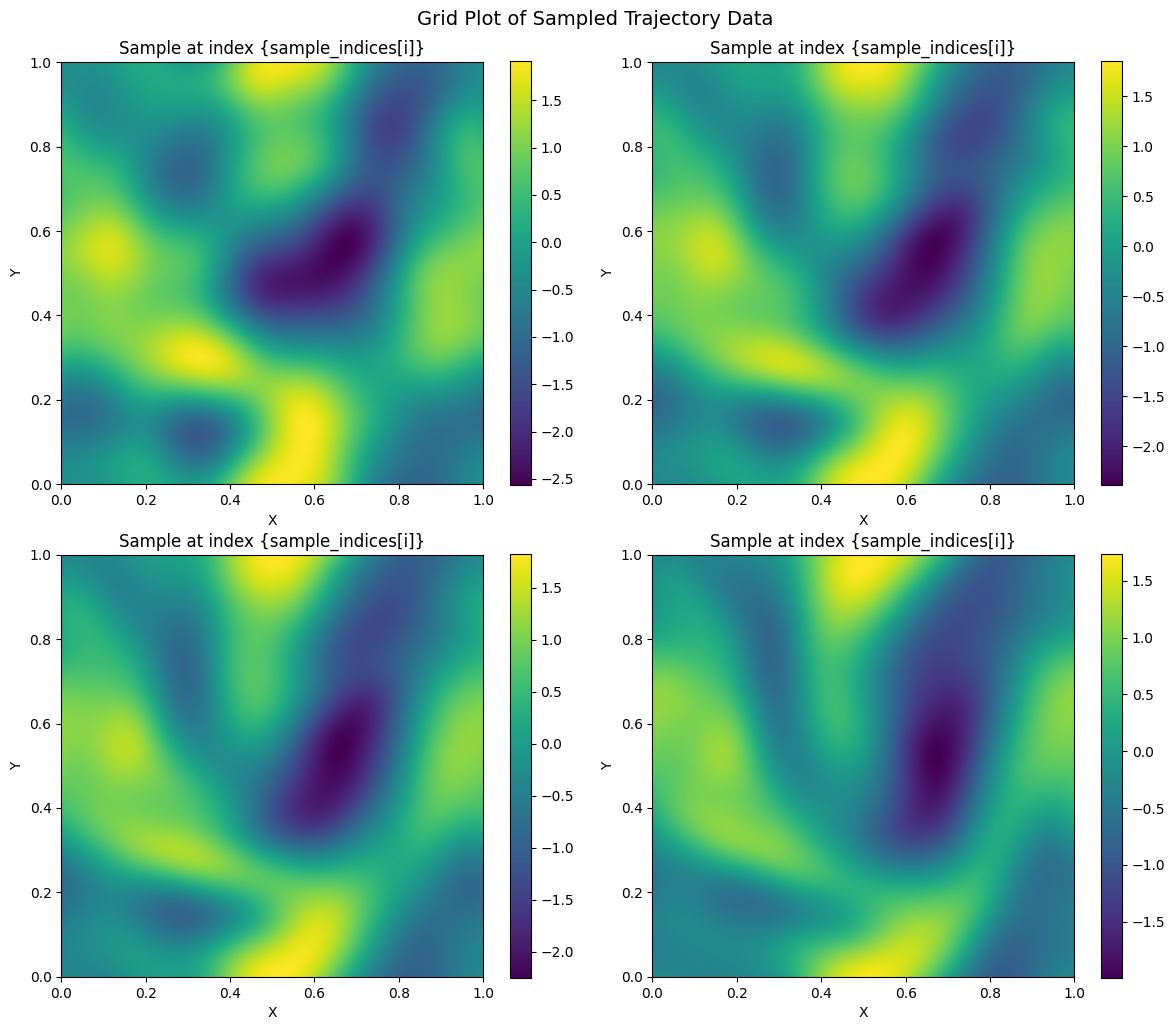

In [ ]:
# plot samples from a single trajectory of data 
param64_data = predictions[50]
sample_indices = np.array([0, 15, 25, 48])
param64_data_samples = param64_data[sample_indices, :, :]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(4):
    # Extract the 2D field
    field = param64_data_samples[i, :, :, 0]

    # imshow instead of contourf
    im = axes[i].imshow(
        field,
        origin="lower",
        extent=[0, 1, 0, 1],  # match domain to [0,1]x[0,1]
        cmap="viridis",
        aspect="equal",
        interpolation="bilinear"
    )
    axes[i].set_title("Sample at index {sample_indices[i]}")
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("Y")
    plt.colorbar(im, ax=axes[i])  # colorbar for each subplot

plt.tight_layout()
plt.suptitle("Grid Plot of Sampled Trajectory Data", y=1.02, fontsize=14)
plt.show()


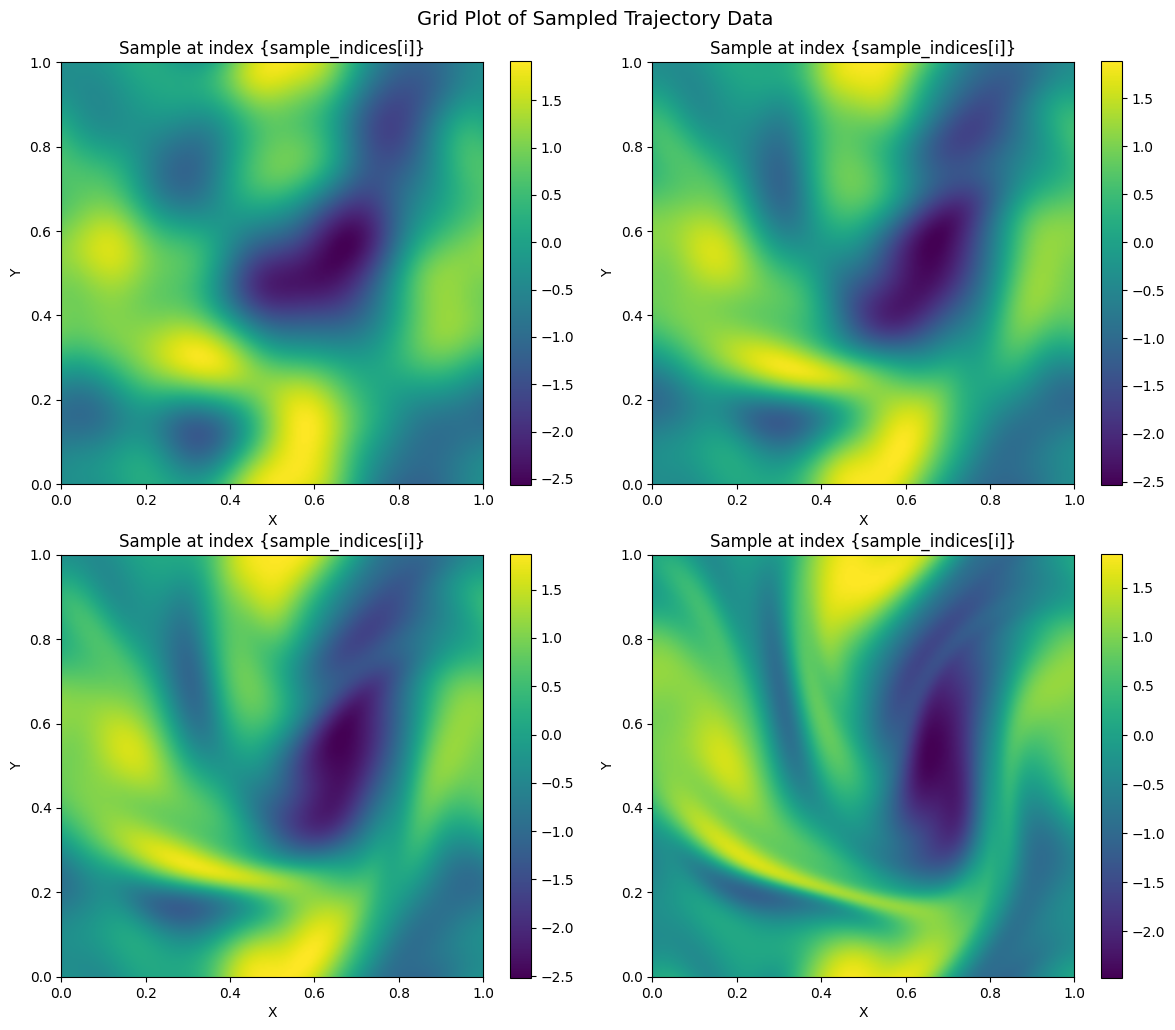

In [4]:
# plot samples from a single trajectory of data 
param64_data = true_data[50]
sample_indices = np.array([0, 15, 25, 48])
param64_data_samples = param64_data[sample_indices, :, :]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(4):
    # Extract the 2D field
    field = param64_data_samples[i, :, :, 0]

    # imshow instead of contourf
    im = axes[i].imshow(
        field,
        origin="lower",
        extent=[0, 1, 0, 1],  # match domain to [0,1]x[0,1]
        cmap="viridis",
        aspect="equal",
        interpolation="bilinear"
    )
    axes[i].set_title("Sample at index {sample_indices[i]}")
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("Y")
    plt.colorbar(im, ax=axes[i])  # colorbar for each subplot

plt.tight_layout()
plt.suptitle("Grid Plot of Sampled Trajectory Data", y=1.02, fontsize=14)
plt.show()


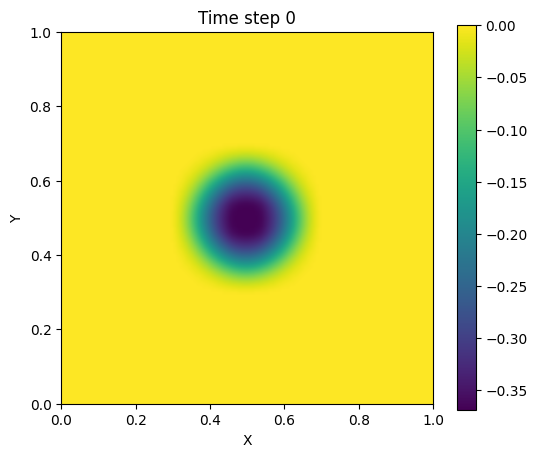

In [209]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

param64_data = predictions[50]  # shape: (T, H, W, 1)
T = param64_data.shape[0]

fig, ax = plt.subplots(figsize=(6, 5))

# Initial frame
field0 = param64_data[0, :, :, 0]
im = ax.imshow(
    field0,
    origin="lower",
    extent=[0, 1, 0, 1],
    cmap="viridis",
    aspect="equal",
    interpolation="bilinear",
)
cbar = plt.colorbar(im, ax=ax)
ax.set_xlabel("X")
ax.set_ylabel("Y")

def update(frame):
    field = param64_data[frame, :, :, 0]
    im.set_array(field)
    ax.set_title(f"Time step {frame}")
    return [im]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=T,
    interval=100,   # ms between frames
    blit=True,
)

plt.show()


In [210]:
ani.save("trajectory_wavelet_sym4.gif", writer="ffmpeg", dpi=150)

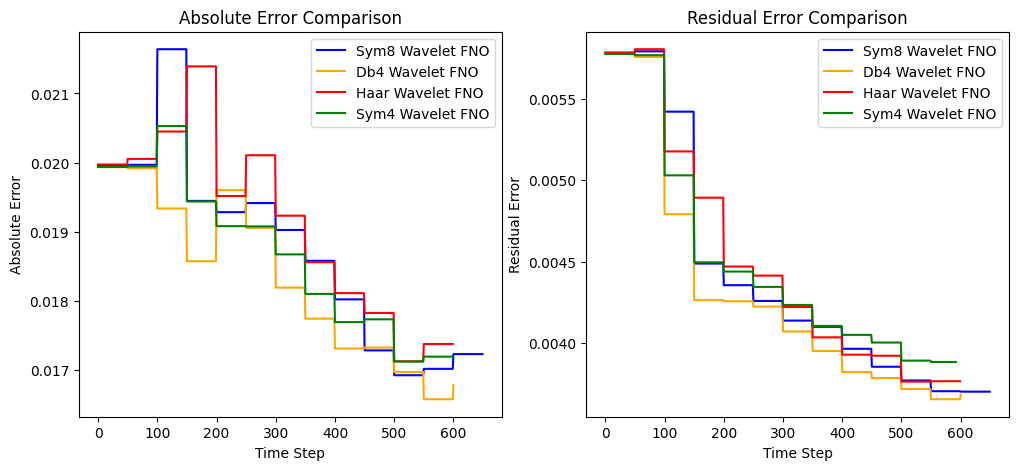

In [211]:
# compare the absolute, residual errors of all three - original, sym8, db4 - wavelet based multiscale FNOs 
sym8_abs = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/test_wavelet_recombine2/metric.erra.npy")
sym8_res = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/test_wavelet_recombine2/metric.residual.npy")
db4_abs = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/test_wavelet_db4/metric.erra.npy")
haar_abs = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/test_wavelet_haar/metric.erra.npy")
haar_res = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/test_wavelet_haar/metric.residual.npy")
db4_res = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/test_wavelet_db4/metric.residual.npy")
sym4_abs = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/test_wavelet_sym4/metric.erra.npy")
sym4_res = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/test_wavelet_sym4/metric.residual.npy")
original_abs = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/fixed_scaling_prelim/metric.erra.npy")
original_res = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/fixed_scaling_prelim/metric.residual.npy")


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(sym8_abs, label="Sym8 Wavelet FNO", color="blue")
plt.plot(db4_abs, label="Db4 Wavelet FNO", color="orange")
plt.plot(haar_abs, label="Haar Wavelet FNO", color="red")
plt.plot(sym4_abs, label="Sym4 Wavelet FNO", color="green")
# plt.plot(original_abs[:600], label="Original NSM", color="green")
plt.xlabel("Time Step")
plt.ylabel("Absolute Error")
plt.title("Absolute Error Comparison")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(sym8_res, label="Sym8 Wavelet FNO", color="blue")
plt.plot(db4_res, label="Db4 Wavelet FNO", color="orange")
plt.plot(haar_res, label="Haar Wavelet FNO", color="red")
plt.plot(sym4_res, label="Sym4 Wavelet FNO", color="green")
# plt.plot(original_res[:600], label="Original NSM", color="green")
plt.xlabel("Time Step")
plt.ylabel("Residual Error")
plt.title("Residual Error Comparison")
plt.legend()

### Wavelet Refiner